In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Better Sizing
plt.rcParams["figure.figsize"] = (8, 6)

df = pd.read_csv("/Users/deep/Desktop/Projects/ecommerce-profit-optimization/data/processed/cleaned_superstore.csv")

df.head()

,ï»¿row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub_category,product_name,sales,quantity,discount,profit,profit_margin,order_year,order_month
0,1,CA-2016-152156,2016-08-11,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,2016,2016-08
1,2,CA-2016-152156,2016-08-11,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,2016,2016-08
2,3,CA-2016-138688,2016-12-06,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,2016,2016-12
3,4,US-2015-108966,2015-11-10,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,2015,2015-11
4,5,US-2015-108966,2015-11-10,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,2015,2015-11


# E-commerce Profit Optimization Engine — EDA

## Objective
Identify how discounting impacts profitability across products and categories, and uncover opportunities for profit optimization.

## 1. Sales vs Profit
Are high-sales transactions always profitable?

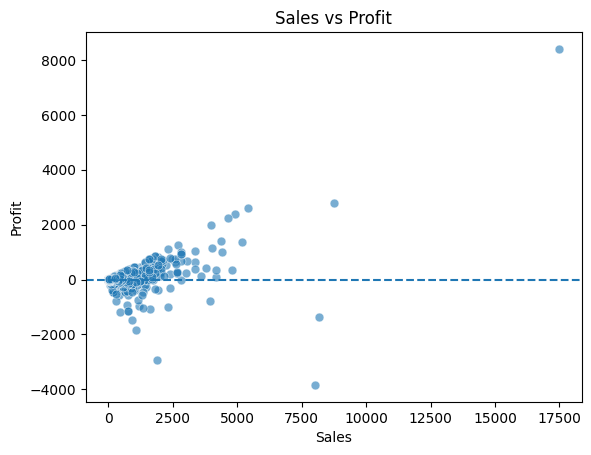

In [3]:
sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    alpha=0.6,
    s=40
)

plt.axhline(0, linestyle="--")

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

While many transactions cluster around low sales and near-zero profit, several high-sales transactions generate significant losses. This indicates that strong revenue performance does not necessarily translate into profitability, highlighting the presence of unprofitable sales strategies or product segments.

## 2. Discount vs Profit
How does discounting impact profitability across transactions?

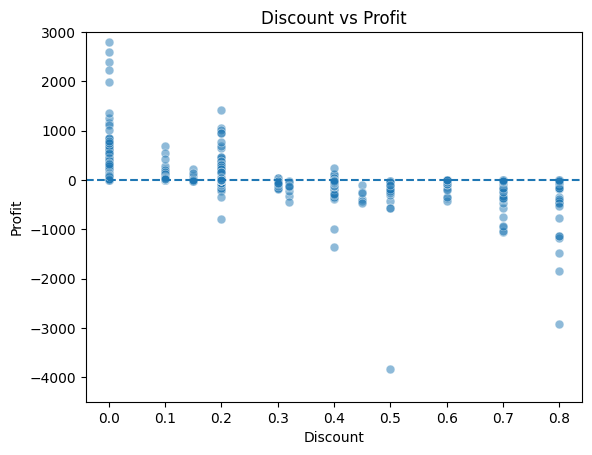

In [7]:
sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    alpha=0.5,
    s=40
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.ylim(-4500, 3000)
plt.show()

Profitability declines significantly as discounts increase. Negative-profit transactions begin appearing around the 20% discount level and become increasingly concentrated at higher discount ranges (40%+), indicating that aggressive discounting is a major driver of losses.

## 3. Profitability by Discount Bucket
At what discount level does profitability turn negative?

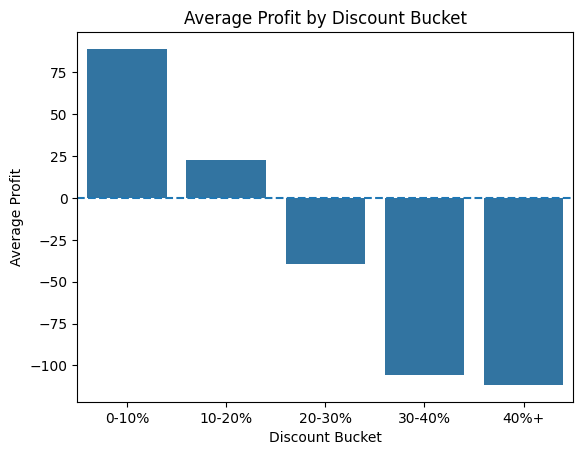

In [9]:
df["discount_bucket"] = pd.cut(
    df["discount"],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 1],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"]
)

bucket_profit = (
    df.groupby("discount_bucket", observed = 'false')["profit"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=bucket_profit,
    x="discount_bucket",
    y="profit"
)

plt.axhline(0, linestyle="--")

plt.title("Average Profit by Discount Bucket")
plt.xlabel("Discount Bucket")
plt.ylabel("Average Profit")

plt.show()

Average profitability turns negative beyond the 20–30% discount range, with losses accelerating sharply at higher discount levels. This confirms that excessive discounting is a primary driver of unprofitable sales and supports implementing discount caps below 20% for sensitive categories.

## 4. Profit Margin by Category
Which product categories contribute most effectively to profitability?

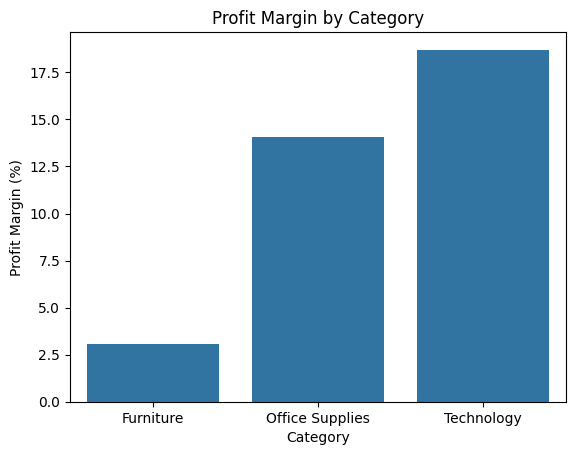

In [12]:
cat_profit = (
    df.groupby("category")[["sales", "profit"]]
    .sum()
    .reset_index()
)

cat_profit["profit_margin"] = (
    (cat_profit["profit"] / cat_profit["sales"])*100
)

sns.barplot(
    data=cat_profit,
    x="category",
    y="profit_margin"
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.show()

Furniture has the lowest profit margin among all categories, indicating that it contributes weakly to overall profitability and may require tighter pricing and discount controls.

## 5. Revenue Composition
How much revenue is generated from loss-making transactions?

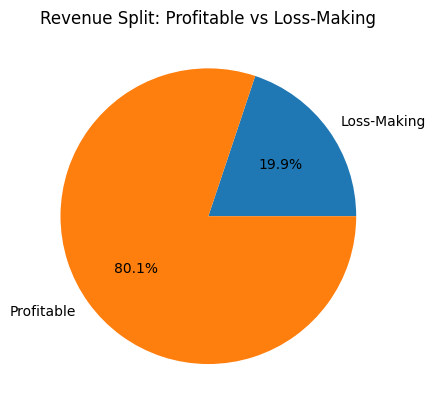

In [13]:
loss_df = df.copy()

loss_df["transaction_type"] = loss_df["profit"].apply(
    lambda x: "Loss-Making" if x < 0 else "Profitable"
)

revenue_split = (
    loss_df.groupby("transaction_type")["sales"]
    .sum()
)

plt.pie(
    revenue_split,
    labels=revenue_split.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Split: Profitable vs Loss-Making")

plt.show()

Approximately 20% of total revenue is generated from loss-making transactions, indicating that a significant portion of sales is actively eroding profitability rather than contributing to business growth.